In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD

import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
class BasicNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.w00 = nn.Parameter(torch.tensor(1.7), requires_grad=False)
        self.b00 = nn.Parameter(torch.tensor(-0.85), requires_grad=False)
        self.w01 = nn.Parameter(torch.tensor(-40.8), requires_grad=False)

        self.w10 = nn.Parameter(torch.tensor(12.6), requires_grad=False)
        self.b10 = nn.Parameter(torch.tensor(0.0), requires_grad=False)
        self.w11 = nn.Parameter(torch.tensor(2.7), requires_grad=False)

        self.final_bias = nn.Parameter(torch.tensor(-16), requires_grad=False)

    def forward(self, input):
        input_to_top_relu = input * self.w00 + self.b00
        top_relu_output = F.relu(input_to_top_relu)
        scaled_top_relu_output = top_relu_output * self.w01

        input_to_bottom_relu = input * self.w10 + self.b10
        bottom_relu_output = F.relu(input_to_bottom_relu)
        scaled_bottom_relu_output = bottom_relu_output * self.w11

        input_to_final_relu = scaled_top_relu_output + scaled_bottom_relu_output + self.final_bias

        output = F.relu(input_to_final_relu)

        return output

In [35]:
input_doses = torch.linspace(start=0, end=1, steps=11)
input_doses

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000, 1.0000])

In [36]:
model = BasicNN() # init
output_values = model(input_doses) # forward
output_values

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0100, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000])

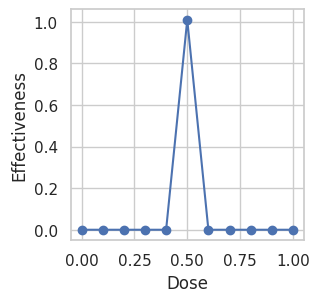

In [37]:
plt.figure(figsize=(3,3))
plt.scatter(input_doses, output_values, linewidths=1)
plt.plot(input_doses, output_values)
plt.ylabel("Effectiveness")
plt.xlabel("Dose")
plt.show()

In [38]:
class BasicNN_train(nn.Module):
    def __init__(self):
        super().__init__()

        self.w00 = nn.Parameter(torch.tensor(1.7), requires_grad=False)
        self.b00 = nn.Parameter(torch.tensor(-0.85), requires_grad=False)
        self.w01 = nn.Parameter(torch.tensor(-40.8), requires_grad=False)

        self.w10 = nn.Parameter(torch.tensor(12.6), requires_grad=False)
        self.b10 = nn.Parameter(torch.tensor(0.0), requires_grad=False)
        self.w11 = nn.Parameter(torch.tensor(2.7), requires_grad=False)

        self.final_bias = nn.Parameter(torch.tensor(0.0), requires_grad=True)

    def forward(self, input):
        input_to_top_relu = input * self.w00 + self.b00
        top_relu_output = F.relu(input_to_top_relu)
        scaled_top_relu_output = top_relu_output * self.w01

        input_to_bottom_relu = input * self.w10 + self.b10
        bottom_relu_output = F.relu(input_to_bottom_relu)
        scaled_bottom_relu_output = bottom_relu_output * self.w11

        input_to_final_relu = scaled_top_relu_output + scaled_bottom_relu_output + self.final_bias

        output = F.relu(input_to_final_relu)

        return output

In [39]:
model = BasicNN_train()
output_values = model(input_doses)
output_values

tensor([ 0.0000,  3.4020,  6.8040, 10.2060, 13.6080, 17.0100, 13.4760,  9.9420,
         6.4080,  2.8740,  0.0000], grad_fn=<ReluBackward0>)

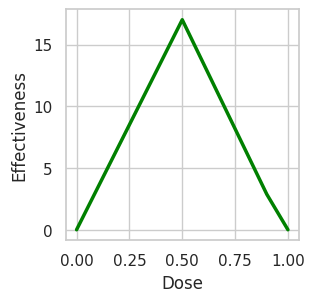

In [40]:
sns.set(style="whitegrid")
plt.figure(figsize=(3,3))
sns.lineplot(x=input_doses,
             y=output_values.detach(),
             color='green', linewidth=2.5)
plt.ylabel("Effectiveness")
plt.xlabel("Dose")
plt.show()

train

In [41]:
inputs = torch.tensor([0., 0.5, 1.,])
labels = torch.tensor([0., 1., 0.,])

In [42]:
optimizer = SGD(model.parameters(), lr=0.1)
print(f"Final bias, before optimization: {model.final_bias.data}")

Final bias, before optimization: 0.0


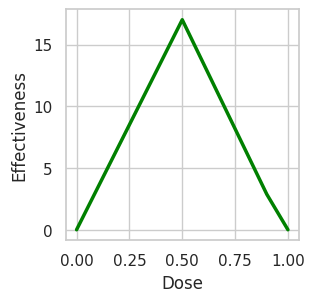

step: 0, Final Bias: -3.202, total_loss = 256.3


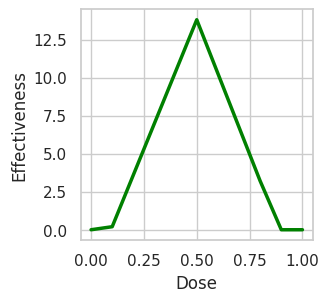

step: 1, Final Bias: -5.7636, total_loss = 164.0


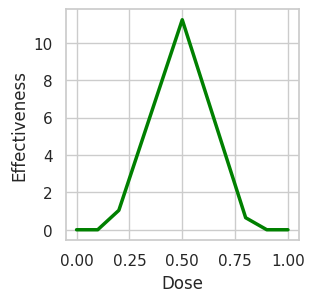

step: 2, Final Bias: -7.8129, total_loss = 105.0


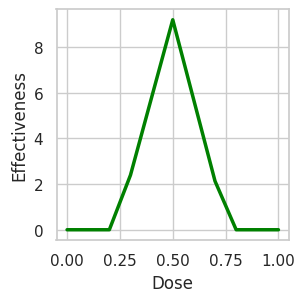

step: 3, Final Bias: -9.4523, total_loss = 67.19


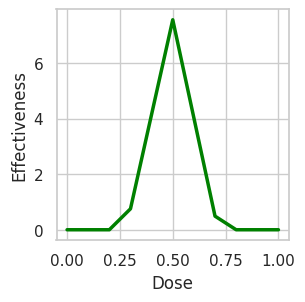

step: 4, Final Bias: -10.764, total_loss = 43.0


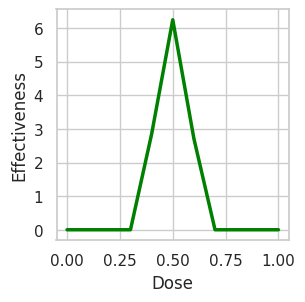

step: 5, Final Bias: -11.813, total_loss = 27.52


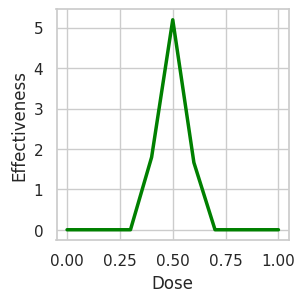

step: 6, Final Bias: -12.652, total_loss = 17.61


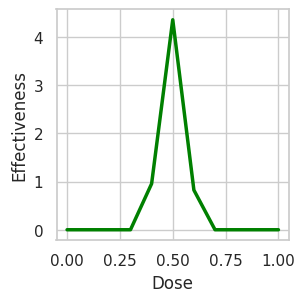

step: 7, Final Bias: -13.324, total_loss = 11.27


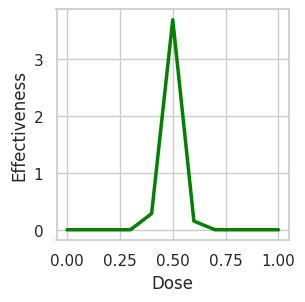

step: 8, Final Bias: -13.861, total_loss = 7.215


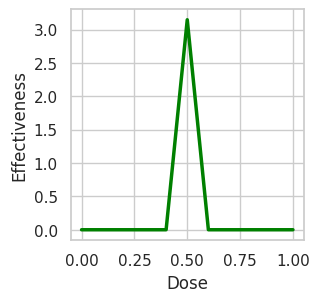

step: 9, Final Bias: -14.291, total_loss = 4.617


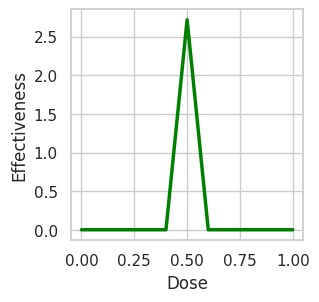

step: 10, Final Bias: -14.635, total_loss = 2.955


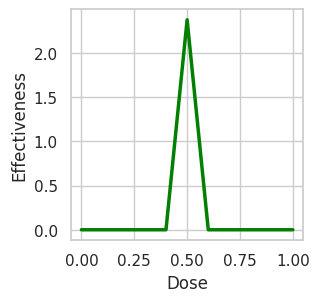

step: 11, Final Bias: -14.91, total_loss = 1.891


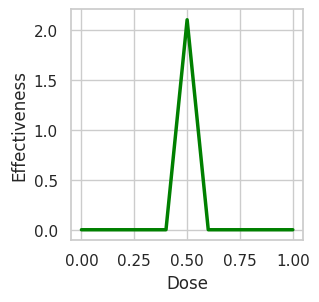

step: 12, Final Bias: -15.13, total_loss = 1.21


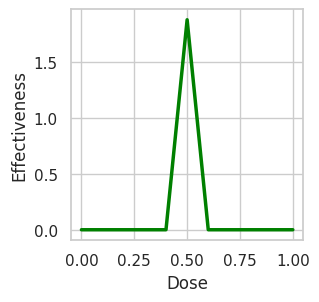

step: 13, Final Bias: -15.306, total_loss = 0.7747


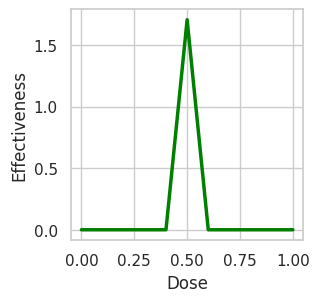

step: 14, Final Bias: -15.447, total_loss = 0.4958


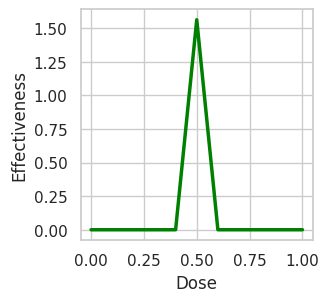

step: 15, Final Bias: -15.559, total_loss = 0.3173


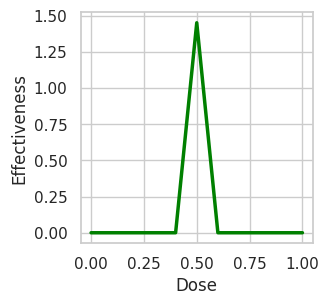

step: 16, Final Bias: -15.649, total_loss = 0.2031


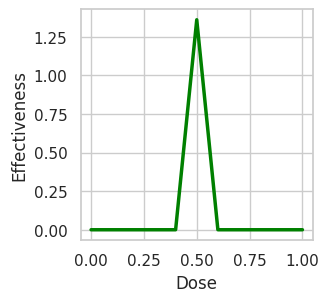

step: 17, Final Bias: -15.722, total_loss = 0.13


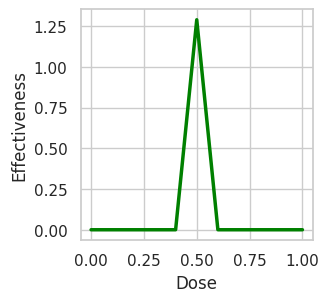

step: 18, Final Bias: -15.779, total_loss = 0.08318


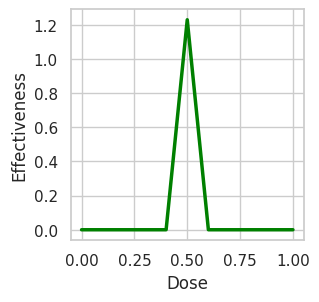

step: 19, Final Bias: -15.825, total_loss = 0.05324


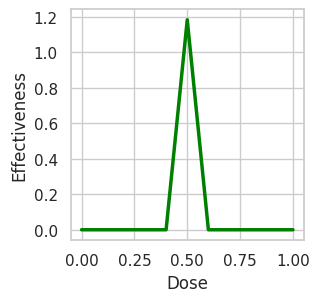

step: 20, Final Bias: -15.862, total_loss = 0.03407


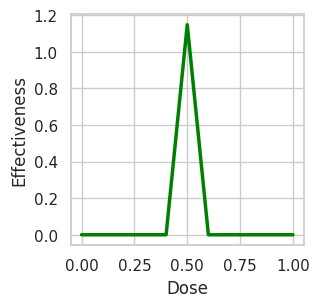

step: 21, Final Bias: -15.892, total_loss = 0.02181


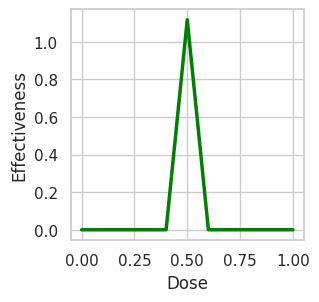

step: 22, Final Bias: -15.915, total_loss = 0.01396


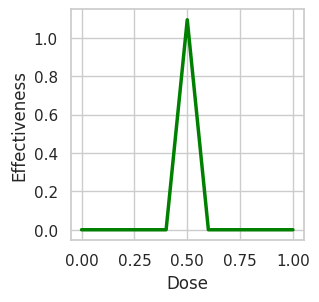

step: 23, Final Bias: -15.934, total_loss = 0.008932


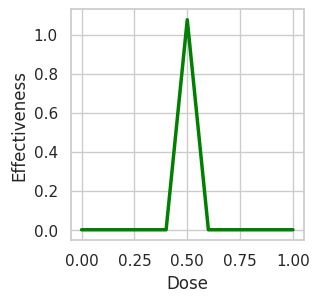

step: 24, Final Bias: -15.95, total_loss = 0.005716


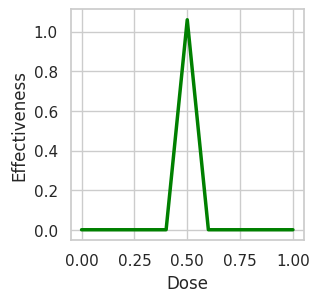

step: 25, Final Bias: -15.962, total_loss = 0.003658


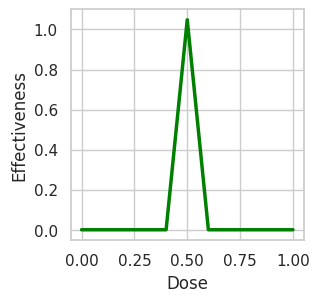

step: 26, Final Bias: -15.971, total_loss = 0.002341


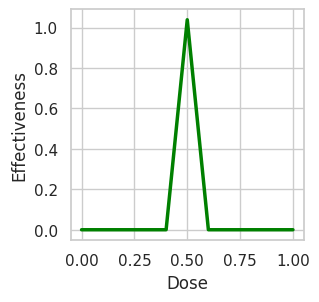

step: 27, Final Bias: -15.979, total_loss = 0.001498


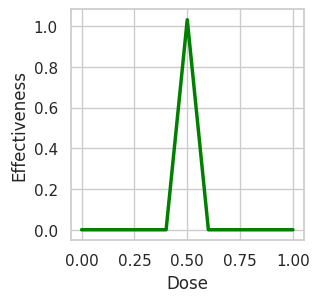

step: 28, Final Bias: -15.985, total_loss = 0.000959


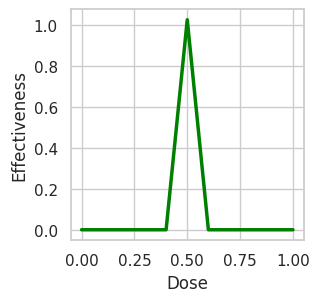

step: 29, Final Bias: -15.99, total_loss = 0.0006138


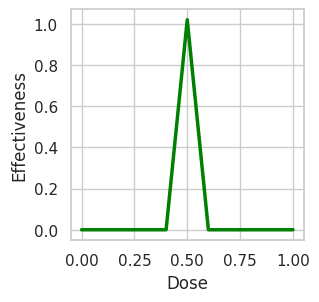

step: 30, Final Bias: -15.994, total_loss = 0.0003928


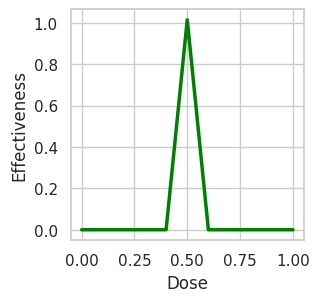

step: 31, Final Bias: -15.997, total_loss = 0.0002514


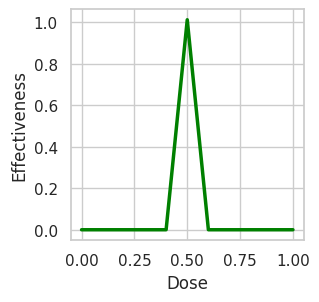

step: 32, Final Bias: -16.0, total_loss = 0.0001609


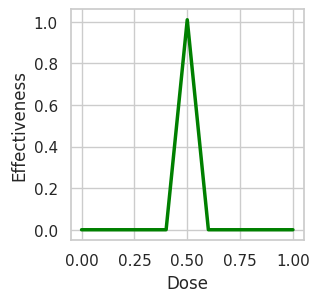

step: 33, Final Bias: -16.002, total_loss = 0.000103


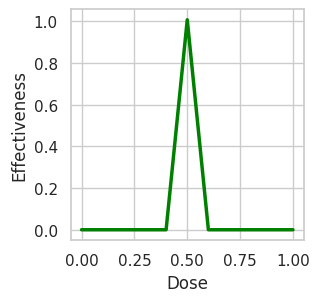

Num steps = 34


In [43]:
for epoch in range(100):

    total_loss = 0

    for iteration in range(len(inputs)):

        input_i = inputs[iteration]
        labels_i = labels[iteration] # y true

        output_i = model(input_i) # y pred

        loss = (output_i - labels_i) ** 2 # SR

        loss.backward() # d_loss_1 / d_b_final # add to the previous derivitive!
        # optimizer.step() # update final bias
        # optimizer.zero_grad() # reset accumulation

        total_loss += float(loss)


    output_values = model(input_doses)
    sns.set(style="whitegrid")
    plt.figure(figsize=(3,3))
    sns.lineplot(x=input_doses,
                y=output_values.detach(),
                color='green', linewidth=2.5)
    plt.ylabel("Effectiveness")
    plt.xlabel("Dose")
    plt.show()

    if total_loss < 0.0001:
        print(f"Num steps = {epoch}")
        break

    optimizer.step() # update final bias
    optimizer.zero_grad() # reset accumulation

    print(f"step: {epoch}, Final Bias: {model.final_bias.data:.5}, total_loss = {total_loss:.4}")



In [44]:
print(f"Final bias , after optimization: {model.final_bias.data:.3}")

Final bias , after optimization: -16.0


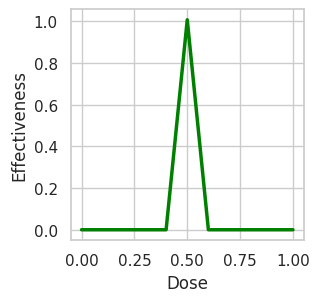

In [45]:
output_values = model(input_doses)

sns.set(style="whitegrid")
plt.figure(figsize=(3,3))
sns.lineplot(x=input_doses,
             y=output_values.detach(),
             color='green', linewidth=2.5)
plt.ylabel("Effectiveness")
plt.xlabel("Dose")
plt.show()

# lightning

In [46]:
import lightning as L
from torch.utils.data import TensorDataset, DataLoader # for large datasets
from lightning.pytorch.tuner import Tuner

In [47]:
class BasicLightning(L.LightningModule):
    def __init__(self):
        super().__init__()

        self.w00 = nn.Parameter(torch.tensor(1.7), requires_grad=False)
        self.b00 = nn.Parameter(torch.tensor(-0.85), requires_grad=False)
        self.w01 = nn.Parameter(torch.tensor(-40.8), requires_grad=False)

        self.w10 = nn.Parameter(torch.tensor(12.6), requires_grad=False)
        self.b10 = nn.Parameter(torch.tensor(0.0), requires_grad=False)
        self.w11 = nn.Parameter(torch.tensor(2.7), requires_grad=False)

        self.final_bias = nn.Parameter(torch.tensor(-16), requires_grad=False)

    def forward(self, input):
        input_to_top_relu = input * self.w00 + self.b00
        top_relu_output = F.relu(input_to_top_relu)
        scaled_top_relu_output = top_relu_output * self.w01

        input_to_bottom_relu = input * self.w10 + self.b10
        bottom_relu_output = F.relu(input_to_bottom_relu)
        scaled_bottom_relu_output = bottom_relu_output * self.w11

        input_to_final_relu = scaled_top_relu_output + scaled_bottom_relu_output + self.final_bias

        output = F.relu(input_to_final_relu)

        return output

Test

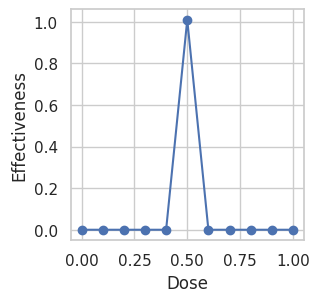

In [48]:
input_doses = torch.linspace(start=0, end=1, steps=11)
model = BasicLightning() # init
output_values = model(input_doses) # forward

plt.figure(figsize=(3,3))
plt.scatter(input_doses, output_values, linewidths=1)
plt.plot(input_doses, output_values)
plt.ylabel("Effectiveness")
plt.xlabel("Dose")
plt.show()

In [49]:
class BasicLightningTrain(L.LightningModule):
    def __init__(self):
        super().__init__()

        self.w00 = nn.Parameter(torch.tensor(1.7), requires_grad=False)
        self.b00 = nn.Parameter(torch.tensor(-0.85), requires_grad=False)
        self.w01 = nn.Parameter(torch.tensor(-40.8), requires_grad=False)

        self.w10 = nn.Parameter(torch.tensor(12.6), requires_grad=False)
        self.b10 = nn.Parameter(torch.tensor(0.0), requires_grad=False)
        self.w11 = nn.Parameter(torch.tensor(2.7), requires_grad=False)

        self.final_bias = nn.Parameter(torch.tensor(0.0), requires_grad=True)

        self.learning_rate = 0.1 # new

    def forward(self, input):
        input_to_top_relu = input * self.w00 + self.b00
        top_relu_output = F.relu(input_to_top_relu)
        scaled_top_relu_output = top_relu_output * self.w01

        input_to_bottom_relu = input * self.w10 + self.b10
        bottom_relu_output = F.relu(input_to_bottom_relu)
        scaled_bottom_relu_output = bottom_relu_output * self.w11

        input_to_final_relu = scaled_top_relu_output + scaled_bottom_relu_output + self.final_bias

        output = F.relu(input_to_final_relu)

        return output

    # LR will be improved on the fly!
    def configure_optimizers(self):
        return SGD(self.parameters(), lr=self.learning_rate)

    def training_step(self, batch, batch_idx):
        input_i, label_i = batch
        output_i = self.forward(input_i)
        loss = (output_i - label_i) ** 2
        return loss

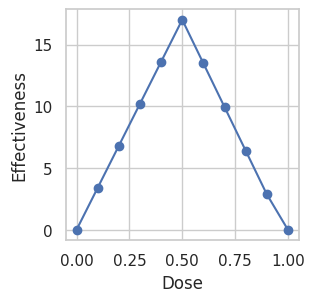

In [50]:
model = BasicLightningTrain() # init
output_values = model(input_doses) # forward

plt.figure(figsize=(3,3))
plt.scatter(input_doses, output_values.detach(), linewidths=1) # detach - only values without grads
plt.plot(input_doses, output_values.detach())
plt.ylabel("Effectiveness")
plt.xlabel("Dose")
plt.show()

In [51]:
dataset = TensorDataset(inputs, labels)

# DataLoader useful for lots of data:
# 1. make it easy to access the data in batches
# 2. easy to shuffle the data each epoch
# 3. easy to use small fraction of the data for quick train for debug
dataloader = DataLoader(dataset)

In [52]:
trainer = L.Trainer(max_epochs=34, accelerator='auto', devices='auto')
tuner = Tuner(trainer)

lr_find_results = tuner.lr_find(model,
                                train_dataloaders=dataloader,
                                # min_lr=0.001,
                                # max_lr=1.0,
                                # early_stop_threshold=None
                                )

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`weights_only` was not set, defaulting to `False`.
/root/dvir.hershkovits/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/root/dvir.hershkovits/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the va

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

LR finder stopped early after 2 steps due to diverging loss.
Restoring states from the checkpoint path at /root/python_ml/.lr_find_d6218d12-0d5b-4a2b-9718-d795d07d9d96.ckpt
Restored all states from the checkpoint at /root/python_ml/.lr_find_d6218d12-0d5b-4a2b-9718-d795d07d9d96.ckpt
Failed to compute suggestion for learning rate because there are not enough points. Increase the loop iteration limits or the size of your dataset/dataloader.


In [53]:
# new_lr = lr_find_results.suggestion()
# print(f"lr_find() suggests {new_lr:.5f} for the LR")

In [54]:
# model.learning_rate = new_lr

Training model

In [ ]:
trainer.fit(model, train_dataloaders=dataloader)

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type ┃ Params ┃ Mode ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━┩
│   │ other params │ n/a  │      7 │ n/a  │   n/a │
└───┴──────────────┴──────┴────────┴──────┴───────┘

Trainable params: 1                                                                                                
Non-trainable params: 6                                                                                            
Total params: 7                                                                                                    
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 0                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

In [ ]:
print(model.final_bias.data)

tensor(-16.0019)


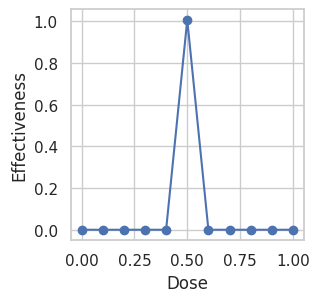

In [ ]:
output_values = model(input_doses)

plt.figure(figsize=(3,3))
plt.scatter(input_doses, output_values.detach(), linewidths=1) # detach - only values without grads
plt.plot(input_doses, output_values.detach())
plt.ylabel("Effectiveness")
plt.xlabel("Dose")
plt.show()

# Chapter 3 - Neural Networks with Multiple Inputs and Outputs!!!

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

import lightning as L
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [6]:
df = pd.read_csv("Iris.csv")
df.head(2)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa


In [7]:
df.drop(columns=['Id'], inplace=True)
df.head(2)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa


In [8]:
df.columns = ["sepal_length",
              "sepal_width",
              "petal_length",
              "petal_width",
              "class"]
df.head(2)

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa


In [9]:
df.shape

(150, 5)

In [11]:
df['class'].unique()

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

In [ ]:
for class_name in df['class'].unique():
    print(f"class_name = {class_name} : {sum(df['class'] == class_name)}")

class_name = Iris-setosa : 50
class_name = Iris-versicolor : 50
class_name = Iris-virginica : 50


In [18]:
df[['petal_width', 'sepal_width']].head(2)

,petal_width,sepal_width
0,0.2,3.5
1,0.2,3.0


In [19]:
input_values = df[['petal_width', 'sepal_width']]
input_values.head(2)

,petal_width,sepal_width
0,0.2,3.5
1,0.2,3.0


In [45]:
label_values = df['class']
type(label_values)

pandas.Series

In [30]:
classes_as_numbers = label_values.factorize()[0]
classes_as_numbers

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [32]:
input_train, input_test, label_train, label_test = train_test_split(input_values,
                                                                    classes_as_numbers,
                                                                    test_size=0.25,
                                                                    stratify=classes_as_numbers,
                                                                    random_state=13)

In [35]:
input_train.shape, label_train.shape

((112, 2), (112,))

In [36]:
input_test.shape, label_test.shape

((38, 2), (38,))

In [44]:
one_hot_label_train = F.one_hot(torch.tensor(label_train)).type(torch.float32)
one_hot_label_train[:10]

tensor([[0., 0., 1.],
        [0., 1., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 0., 1.]])

In [46]:
max_vals_in_input_train = input_train.max()
max_vals_in_input_train

petal_width    2.5
sepal_width    4.4
dtype: float64

In [47]:
min_vals_in_input_train = input_train.min()
min_vals_in_input_train

petal_width    0.1
sepal_width    2.0
dtype: float64

In [48]:
input_train = (input_train - min_vals_in_input_train) / (max_vals_in_input_train - min_vals_in_input_train)
input_train.head()

,petal_width,sepal_width
125,0.708333,0.500000
62,0.375000,0.083333
23,0.166667,0.541667
45,0.083333,0.416667
120,0.916667,0.500000


In [49]:
input_test = (input_test - min_vals_in_input_train) / (max_vals_in_input_train - min_vals_in_input_train)
input_test.head()

,petal_width,sepal_width
148,0.916667,0.583333
118,0.916667,0.250000
13,0.000000,0.416667
127,0.708333,0.416667
95,0.458333,0.416667
